# Thyroid Cancer Recurrence Prediction
### Dataset: Differentiated Thyroid Cancer Recurrence (UCI / Kaggle)
**Task:** Binary Classification — Predict whether thyroid cancer recurs (Yes/No)  
**Domain:** Healthcare — Oncology  
**Models:** Logistic Regression, Random Forest, SVM, Gradient Boosting, ANN (Deep Learning)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('/content/Thyroid_Diff.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()


Dataset Shape: (383, 17)

Column Names: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## 3. Data Pre-processing
### 3a. Missing Values

In [3]:
missing_values = df.isnull().sum()
print('Missing values per column:\n', missing_values)


Missing values per column:
 Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [4]:
# Fill missing numerical values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after imputation:', df.isnull().sum().sum())


Missing values after imputation: 0


### 3b. Duplicate Rows

In [5]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)


Duplicate rows: 19
Shape after removing duplicates: (364, 17)


### 3c. Encode Categorical Features

In [6]:
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print('Encoding complete. Data types after encoding:')
print(df.dtypes)


Encoding complete. Data types after encoding:
Age                     int64
Gender                  int64
Smoking                 int64
Hx Smoking              int64
Hx Radiothreapy         int64
Thyroid Function        int64
Physical Examination    int64
Adenopathy              int64
Pathology               int64
Focality                int64
Risk                    int64
T                       int64
N                       int64
M                       int64
Stage                   int64
Response                int64
Recurred                int64
dtype: object


### 3d. Feature / Target Split & Scaling

In [7]:
# Target: Recurred (0 = No Recurrence, 1 = Recurred)
X = df.drop('Recurred', axis=1)
y = df['Recurred']

print('Feature shape:', X.shape)
print('Target distribution (0=No Recurrence, 1=Recurred):\n', y.value_counts())


Feature shape: (364, 16)
Target distribution (0=No Recurrence, 1=Recurred):
 Recurred
0    256
1    108
Name: count, dtype: int64


In [8]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)


Train size: (291, 16)
Test size : (73, 16)


### 3e. Handle Class Imbalance — SMOTE

In [9]:
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Class distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts())


Class distribution after SMOTE:
Recurred
1    205
0    205
Name: count, dtype: int64


## 4. Model Training & Evaluation
> **Evaluation Metrics:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix, ROC-AUC  
> **Labels:** 0 = No Recurrence, 1 = Recurred


### 4a. Logistic Regression (Baseline)

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_lr))


Logistic Regression Accuracy: 0.8493150684931506
               precision    recall  f1-score   support

No Recurrence       0.88      0.90      0.89        51
     Recurred       0.76      0.73      0.74        22

     accuracy                           0.85        73
    macro avg       0.82      0.81      0.82        73
 weighted avg       0.85      0.85      0.85        73

Confusion Matrix:
 [[46  5]
 [ 6 16]]
ROC-AUC: 0.9206773618538324


### 4b. Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_rf))


Random Forest Accuracy: 0.9452054794520548
               precision    recall  f1-score   support

No Recurrence       0.98      0.94      0.96        51
     Recurred       0.88      0.95      0.91        22

     accuracy                           0.95        73
    macro avg       0.93      0.95      0.94        73
 weighted avg       0.95      0.95      0.95        73

Confusion Matrix:
 [[48  3]
 [ 1 21]]
ROC-AUC: 0.9696969696969698


### 4c. Support Vector Machine (SVM)

In [12]:
svm_base = LinearSVC(max_iter=5000, class_weight='balanced')
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

print('SVM Accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_svm))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_svm))


SVM Accuracy: 0.8493150684931506
               precision    recall  f1-score   support

No Recurrence       0.90      0.88      0.89        51
     Recurred       0.74      0.77      0.76        22

     accuracy                           0.85        73
    macro avg       0.82      0.83      0.82        73
 weighted avg       0.85      0.85      0.85        73

Confusion Matrix:
 [[45  6]
 [ 5 17]]
ROC-AUC: 0.9269162210338682


### 4d. Gradient Boosting

In [13]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print('Gradient Boosting Accuracy:', accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_gb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_gb))


Gradient Boosting Accuracy: 0.9315068493150684
               precision    recall  f1-score   support

No Recurrence       0.98      0.92      0.95        51
     Recurred       0.84      0.95      0.89        22

     accuracy                           0.93        73
    macro avg       0.91      0.94      0.92        73
 weighted avg       0.94      0.93      0.93        73

Confusion Matrix:
 [[47  4]
 [ 1 21]]
ROC-AUC: 0.9812834224598931


## 5. Hyperparameter Tuning — Random Forest

In [14]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions={
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', None]
    },
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_smote, y_train_smote)
print('Best Parameters:', random_search.best_params_)


Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': None}


In [15]:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print('Tuned Random Forest Accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_best))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_best))


Tuned Random Forest Accuracy: 0.9315068493150684
               precision    recall  f1-score   support

No Recurrence       0.98      0.92      0.95        51
     Recurred       0.84      0.95      0.89        22

     accuracy                           0.93        73
    macro avg       0.91      0.94      0.92        73
 weighted avg       0.94      0.93      0.93        73

Confusion Matrix:
 [[47  4]
 [ 1 21]]
ROC-AUC: 0.9737076648841355


## 6. ROC Curve — All ML Models

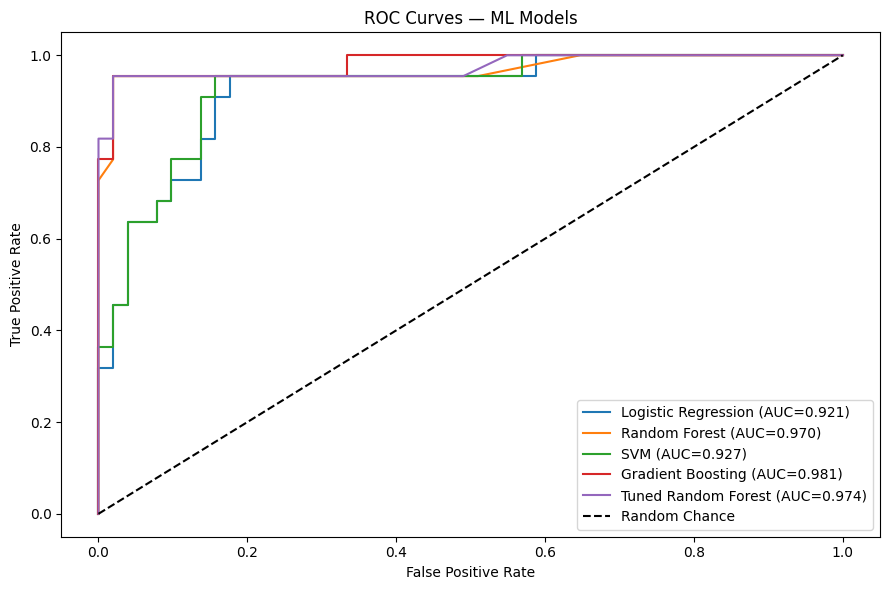

In [16]:
plt.figure(figsize=(9, 6))

models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'SVM': y_prob_svm,
    'Gradient Boosting': y_prob_gb,
    'Tuned Random Forest': y_prob_best,
}

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — ML Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 7. Deep Learning — Artificial Neural Network (ANN)

In [17]:
pip install tensorflow -q


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_smote, y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7561 - loss: 0.6257 - val_accuracy: 0.8537 - val_loss: 0.4881
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8384 - loss: 0.4853 - val_accuracy: 0.8537 - val_loss: 0.3935
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.3786 - val_accuracy: 0.8537 - val_loss: 0.3553
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8598 - loss: 0.3137 - val_accuracy: 0.9146 - val_loss: 0.3026
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9024 - loss: 0.2612 - val_accuracy: 0.9146 - val_loss: 0.2647
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9024 - loss: 0.2449 - val_accuracy: 0.9146 - val_loss: 0.2686
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9177 - loss: 0.2113 - val_accuracy: 0.9146 - val_loss: 0.2358
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9116 - loss: 0.2297 - val_accuracy: 0.9268 - val_lo

### 7a. ANN Training / Validation Loss & Accuracy Curves

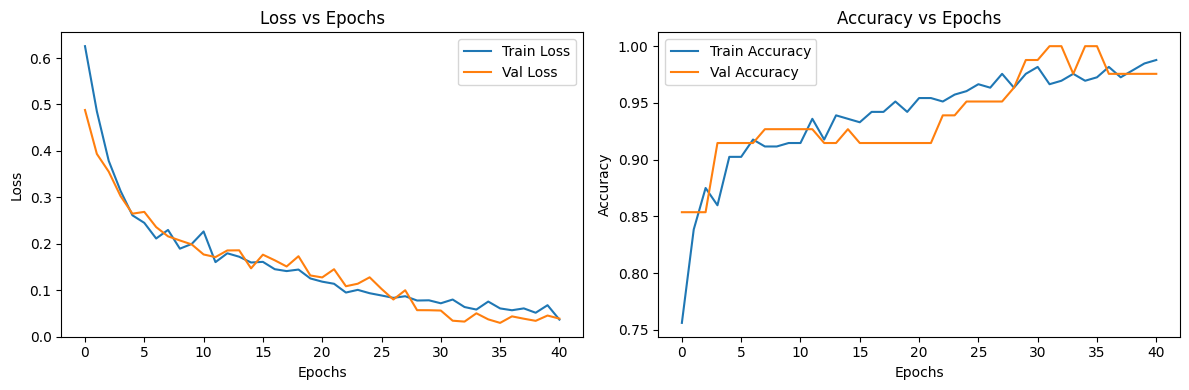

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### 7b. ANN Evaluation

In [20]:
y_pred_ann = (model.predict(X_test) > 0.5).astype(int).flatten()
y_prob_ann = model.predict(X_test).flatten()

print('ANN Accuracy:', accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann, target_names=['No Recurrence', 'Recurred'], zero_division=0))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_ann))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_ann))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
ANN Accuracy: 0.9178082191780822
               precision    recall  f1-score   support

No Recurrence       0.98      0.90      0.94        51
     Recurred       0.81      0.95      0.88        22

     accuracy                           0.92        73
    macro avg       0.89      0.93      0.91        73
 weighted avg       0.93      0.92      0.92        73

Confusion Matrix:
 [[46  5]
 [ 1 21]]
ROC-AUC: 0.964349376114082


## 8. Result Analysis — Model Comparison Summary

In [21]:
results = {
    'Logistic Regression':  {'Accuracy': accuracy_score(y_test, y_pred_lr),
                             'Precision': f1_score(y_test, y_pred_lr, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_lr)},
    'Random Forest':        {'Accuracy': accuracy_score(y_test, y_pred_rf),
                             'Precision': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_rf, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_rf)},
    'SVM':                  {'Accuracy': accuracy_score(y_test, y_pred_svm),
                             'Precision': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_svm)},
    'Gradient Boosting':    {'Accuracy': accuracy_score(y_test, y_pred_gb),
                             'Precision': f1_score(y_test, y_pred_gb, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_gb, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_gb)},
    'Tuned Random Forest':  {'Accuracy': accuracy_score(y_test, y_pred_best),
                             'Precision': f1_score(y_test, y_pred_best, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_best, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_best)},
    'ANN':                  {'Accuracy': accuracy_score(y_test, y_pred_ann),
                             'Precision': f1_score(y_test, y_pred_ann, average='weighted', zero_division=0),
                             'Macro F1':  f1_score(y_test, y_pred_ann, average='macro', zero_division=0),
                             'ROC-AUC':   roc_auc_score(y_test, y_prob_ann)},
}

summary_df = pd.DataFrame(results).T.round(4)
print('='*60)
print('          MODEL COMPARISON SUMMARY')
print('='*60)
print(summary_df.to_string())
print('='*60)
print(f'\nBest Model by Accuracy : {summary_df["Accuracy"].idxmax()}')
print(f'Best Model by ROC-AUC  : {summary_df["ROC-AUC"].idxmax()}')
print(f'Best Model by Macro F1 : {summary_df["Macro F1"].idxmax()}')


          MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Macro F1  ROC-AUC
Logistic Regression    0.8493     0.8483    0.8187   0.9207
Random Forest          0.9452     0.9458    0.9365   0.9697
SVM                    0.8493     0.8502    0.8233   0.9269
Gradient Boosting      0.9315     0.9327    0.9216   0.9813
Tuned Random Forest    0.9315     0.9327    0.9216   0.9737
ANN                    0.9178     0.9196    0.9069   0.9643

Best Model by Accuracy : Random Forest
Best Model by ROC-AUC  : Gradient Boosting
Best Model by Macro F1 : Random Forest


### 8a. Confusion Matrix — Best Model (Tuned Random Forest)

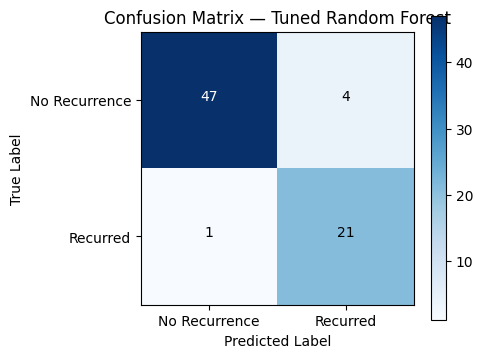

In [22]:
import itertools

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Tuned Random Forest')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['No Recurrence', 'Recurred'])
plt.yticks(tick_marks, ['No Recurrence', 'Recurred'])
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
